## Artifact Removal and signal cleaning

In this notebook, I applied **Independent Component Decomposition (ICA)** to isolate and remove ocular artifacts. Since EEG signals are in the microVolt range, **a single blink can completely obscure cortical activity**.

Using the **EOG channels** as a **reference**, the algorithm **identified components** that had **frontal topography and a high correlation with eye movements**. 

By **removing** these **components**, we have **cleaned the signal** allowing future classification algorithms to **focus** exclusively on the **neural dynamics of Motor Imagery**.


In this notebook, **Subject 1** served as the **pilot subject** for the visualization and artifact-removal workflow. 
Once the **pipeline** was validated on this first case, I **replicated** the same ICA-based preprocessing across the **remaining subjects**.






## Setup, utils and data loading

In [1]:
import mne
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import os
from mne.preprocessing import ICA

# --- UTILS SECTION (Redefined for independence) ---
FS = 250.0 
DATA_PATH = os.path.join('.', 'archive')
SUBJECTS = [f'A{i:02d}T.mat' for i in range(1, 10)]

def load_bci_subject(file_path):
    mat = sio.loadmat(file_path)
    runs = mat['data'][0]
    all_raws = []
    ch_names = ['Fz', 'FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',
                'CP3', 'CPz', 'CP4', 'P1', 'Pz', 'P2', 'POz', 'O1', 'Oz', 'O2', 'P6',
                'EOG-left', 'EOG-central', 'EOG-right']
    
    for run in runs:
        X = run['X'][0,0]
        trial_idx = run['trial'][0,0].flatten()
        y = run['y'][0,0].flatten()
        n_channels = X.shape[1]
        current_ch_names = ch_names[:n_channels]
        ch_types = ['eeg'] * min(n_channels, 22) + ['eog'] * max(0, n_channels - 22)
        info = mne.create_info(ch_names=current_ch_names, sfreq=FS, ch_types=ch_types)
        raw_run = mne.io.RawArray(X.T * 1e-6, info)
        
        event_desc = {1: 'left', 2: 'right', 3: 'foot', 4: 'tongue'}
        annot = mne.Annotations(onset=trial_idx/FS, duration=4.0, 
                                description=[event_desc[label] for label in y])
        raw_run.set_annotations(annot)
        all_raws.append(raw_run)
    
    raw_subject = mne.concatenate_raws(all_raws)
    raw_subject.set_montage(mne.channels.make_standard_montage('standard_1020'), on_missing='ignore')
    return raw_subject

# --- START PROCESSING ---
SUBJECT_ID = 'A01T.mat'
raw = load_bci_subject(os.path.join(DATA_PATH, SUBJECT_ID))

# 1. High-pass filter (CRITICAL for ICA stability)
#  filter at 1Hz to remove slow drifts that confuse the ICA algorithm
raw_ica = raw.copy().filter(l_freq=1.0, h_freq=40.0)

Creating RawArray with float64 data, n_channels=25, n_times=29683
    Range : 0 ... 29682 =      0.000 ...   118.728 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=20172
    Range : 0 ... 20171 =      0.000 ...    80.684 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=41463
    Range : 0 ... 41462 =      0.000 ...   165.848 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      0.000 ...   386.936 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      0.000 ...   386.936 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      0.000 ...   386.936 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      0.000 ...   386.936 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      

## Independent Component Analysis (ICA) on subject 1 (pilot-case)

In [2]:
# Initialize ICA
# n_components=20: I want to explain most of the variance with 20 sources
ica = ICA(n_components=20, 
          max_iter="auto", 
          method='infomax', 
          random_state=42, 
          fit_params=dict(extended=True))

ica.fit(raw_ica)

# Find EOG artifacts automatically
#  use the EOG channels  labeled during loading to find matching patterns
eog_indices, eog_scores = ica.find_bads_eog(raw_ica, ch_name=['EOG-left', 'EOG-central', 'EOG-right'])

ica.exclude = eog_indices
print(f"Components identified as EOG artifacts: {eog_indices}")

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 20 components
Computing Extended Infomax ICA
Fitting ICA took 143.1s.
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower

## Visualizations

1. As shown in the **EOG Component Correlation** plot, the automated correlation algorithm identified Components **ICA001, ICA002, and ICA004 (red bars)** as having the highest statistical **similarity with the EOG channels**. Component **ICA001** shows a **near-maximum negative correlation score**, making it a candidate for an **eye-blink artifact**

---
2. **Morphological validation: ICA Topographies**
I  look at the spatial maps (Topomaps) to ensure they look like biological artifacts.

-  **ICA001 and ICA002**components show a clear, intense frontal scalp distribution. In neurophysiology, this is the classic signature of vertical eye movements and blinks, as the dipole is located directly beneath the forehead electrodes.

- **ICA004** displays a more **lateralized frontal pattern**, typically associated with **horizontal eye movements (saccades)**.

- Neural Components (e.g., ICA007, ICA018): notice how components like **ICA018** show a more localized, **posterior, or central distribution**. These likely represent real **cortical activity or muscle noise** that we choose to **keep for now to avoid losing neural data**.
---

3. **Temporal validation: signal reconstruction** (before vs. after)
The ultimate test is seeing the **cleaned EEG trace**.
 In the raw vs. cleaned comparison (Fz channel), the original signal  was dominated by massive** voltage spikes (reaching over $40 \mu V$) caused by blinks**. These artifacts are several times larger than the underlying Mu-rhythm.After **applying the ICA mask and zeroing out the 3 identified components**, the **cleaned signal**  reveals the actual neural oscillations. The **rhythmic activity** is now visible, providing a stable **baseline for the Common Spatial Patterns (CSP)** algorithm in the next stage.

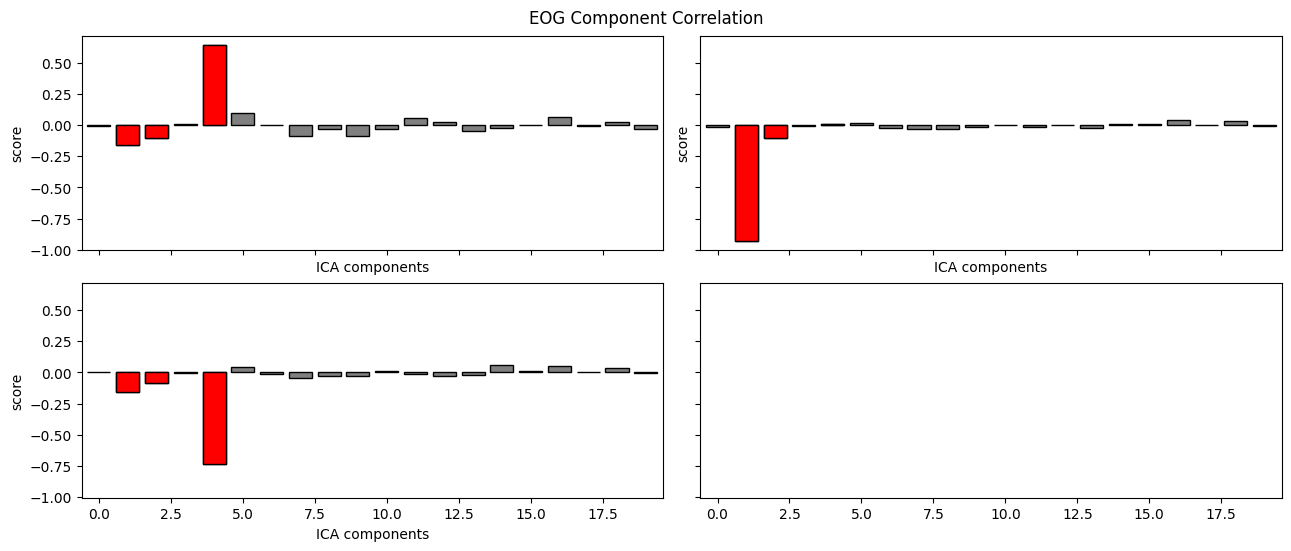

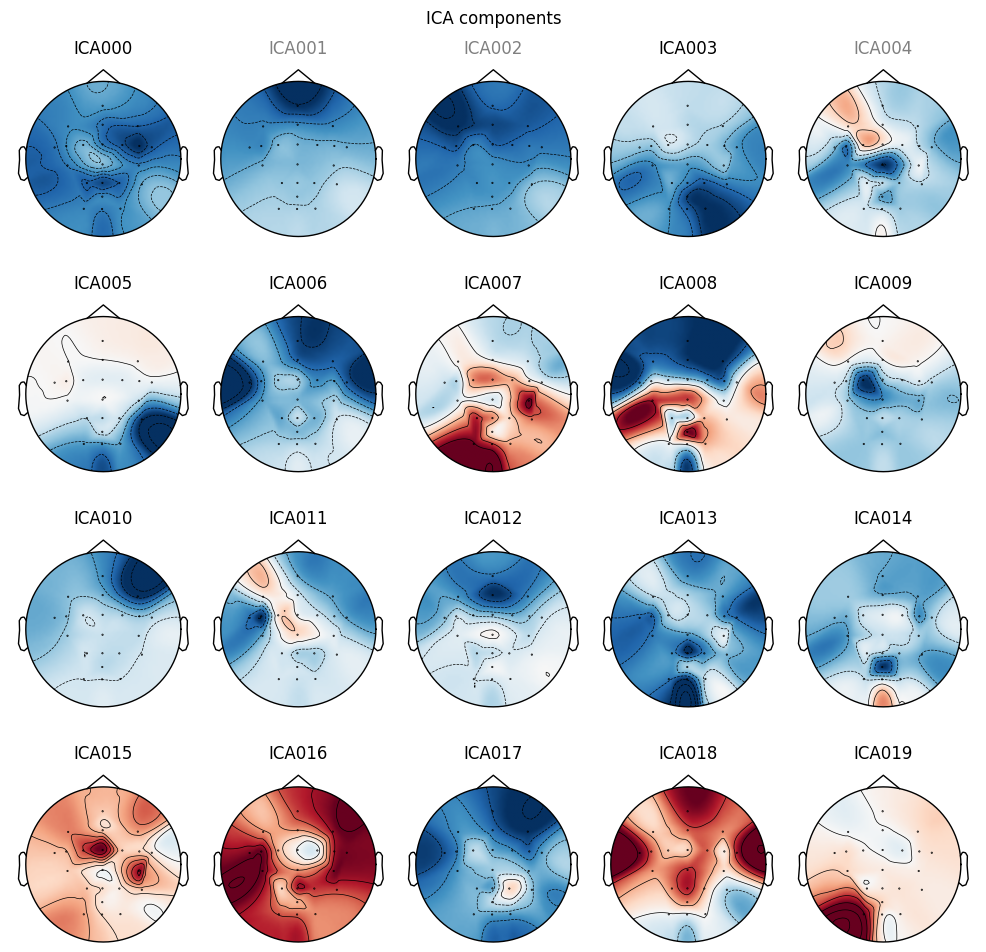

Filtering raw data in 9 contiguous segments
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 3 ICA components
    Projecting back using 22 PCA components
Using matplotlib as 2D backend.


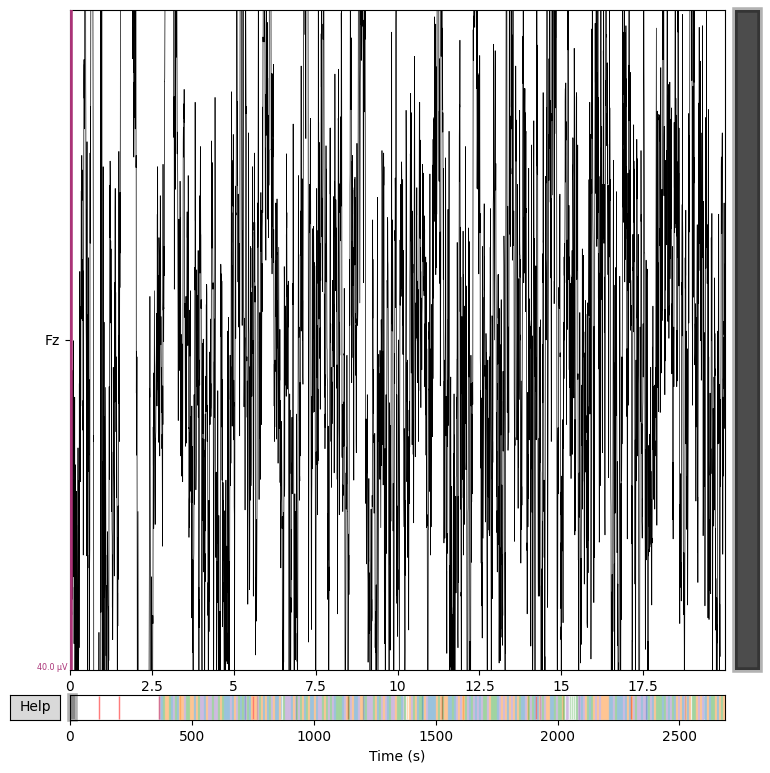

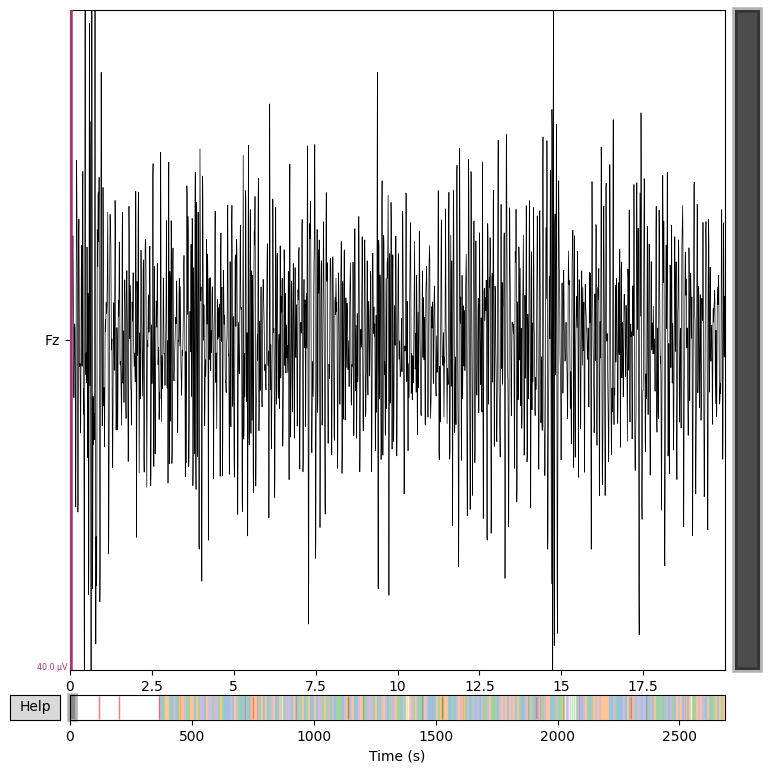

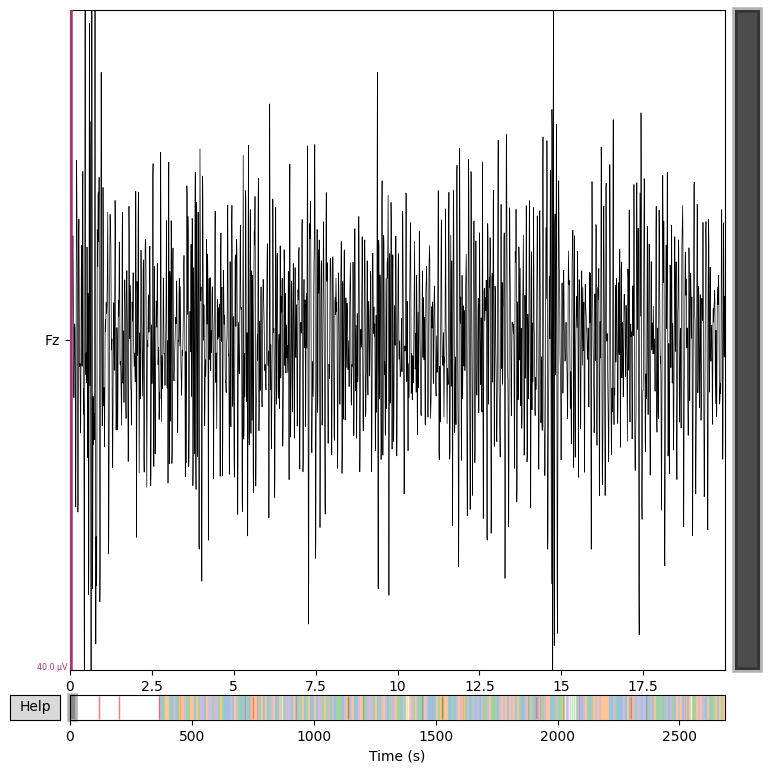

In [3]:
# Plot the distribution of EOG scores across components
ica.plot_scores(eog_scores, title="EOG Component Correlation")

# Plot the spatial map of the components
# A blink component will show a strong concentration in the frontal (top) area
ica.plot_components()

# Visual comparison: Before vs After
# We apply the exclusion to a copy of the raw data filtered for our task (8-30Hz)
raw_clean = raw.copy().filter(l_freq=8.0, h_freq=30.0)
ica.apply(raw_clean)

# Pick a channel near the eyes (e.g., Fz) to see the cleaning effect
raw.plot(order=[0], duration=20, title="Raw with Artifacts")
raw_clean.plot(order=[0], duration=20, title="Cleaned Data")

## Independent Component Analysis (ICA) across subjects

In [4]:
import os

# Create a directory for cleaned data to avoid overwriting originals
output_path = os.path.join('.', 'cleaned_data_1_40')
if not os.path.exists(output_path):
    os.makedirs(output_path)

print(f"Starting Batch Processing for {len(SUBJECTS)} subjects...")

for sub_name in SUBJECTS:
    print(f"\n--- Processing {sub_name} ---")
    
    # 1. Load
    file_path = os.path.join(DATA_PATH, sub_name)
    raw = load_bci_subject(file_path)
    
    # 2. Filter for ICA (1-40 Hz)
    raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=40.0, verbose=False)
    
    # 3. Fit ICA
    ica = ICA(n_components=20, max_iter="auto", method='infomax', 
              random_state=42, fit_params=dict(extended=True))
    ica.fit(raw_for_ica, verbose=False)
    
    # 4. Find and Exclude EOG (Ocular artifacts)
    eog_indices, _ = ica.find_bads_eog(raw_for_ica, 
                                      ch_name=['EOG-left', 'EOG-central', 'EOG-right'], 
                                      verbose=False)
    ica.exclude = eog_indices
    
    # 5. Apply ICA to the task-relevant signal (8-30 Hz)
    raw_clean = raw.copy().filter(l_freq=1.0, h_freq=40.0, verbose=False)
    ica.apply(raw_clean, verbose=False)
    
    # 6. Save the cleaned object
    # Saving as .fif (MNE standard) makes it easier to load in the next notebook
    save_name = sub_name.replace('.mat', '_clean-raw_1_40.fif')
    raw_clean.save(os.path.join(output_path, save_name), overwrite=True)
    
    
    print(f"Successfully cleaned and saved {sub_name} (Excluded {len(eog_indices)} components)")

print("\nAll subjects processed. The 'cleaned_data' folder is ready for Machine Learning.")

Starting Batch Processing for 9 subjects...

--- Processing A01T.mat ---
Creating RawArray with float64 data, n_channels=25, n_times=29683
    Range : 0 ... 29682 =      0.000 ...   118.728 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=20172
    Range : 0 ... 20171 =      0.000 ...    80.684 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=41463
    Range : 0 ... 41462 =      0.000 ...   165.848 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      0.000 ...   386.936 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      0.000 ...   386.936 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      0.000 ...   386.936 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      0.000 ...   386.936 secs
Ready.
Creating RawArray with f

C:\Users\ACER\AppData\Local\Temp\ipykernel_3544\1135671033.py:38: RuntimeWarning: This filename (c:\Users\ACER\Desktop\eeg\cleaned_data_1_40\A01T_clean-raw_1_40.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_clean.save(os.path.join(output_path, save_name), overwrite=True)


Closing c:\Users\ACER\Desktop\eeg\cleaned_data_1_40\A01T_clean-raw_1_40.fif
[done]
Successfully cleaned and saved A01T.mat (Excluded 3 components)

--- Processing A02T.mat ---
Creating RawArray with float64 data, n_channels=25, n_times=31513
    Range : 0 ... 31512 =      0.000 ...   126.048 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=25989
    Range : 0 ... 25988 =      0.000 ...   103.952 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=38457
    Range : 0 ... 38456 =      0.000 ...   153.824 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      0.000 ...   386.936 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      0.000 ...   386.936 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      0.000 ...   386.936 secs
Ready.
Creating RawArray with float64 data, n_channels=25

C:\Users\ACER\AppData\Local\Temp\ipykernel_3544\1135671033.py:38: RuntimeWarning: This filename (c:\Users\ACER\Desktop\eeg\cleaned_data_1_40\A02T_clean-raw_1_40.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_clean.save(os.path.join(output_path, save_name), overwrite=True)


Closing c:\Users\ACER\Desktop\eeg\cleaned_data_1_40\A02T_clean-raw_1_40.fif
[done]
Successfully cleaned and saved A02T.mat (Excluded 2 components)

--- Processing A03T.mat ---
Creating RawArray with float64 data, n_channels=25, n_times=23720
    Range : 0 ... 23719 =      0.000 ...    94.876 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=33872
    Range : 0 ... 33871 =      0.000 ...   135.484 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=21728
    Range : 0 ... 21727 =      0.000 ...    86.908 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      0.000 ...   386.936 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      0.000 ...   386.936 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      0.000 ...   386.936 secs
Ready.
Creating RawArray with float64 data, n_channels=25

...

Closing c:\Users\ACER\Desktop\eeg\cleaned_data_1_40\A07T_clean-raw_1_40.fif
[done]
Successfully cleaned and saved A07T.mat (Excluded 3 components)

--- Processing A08T.mat ---
Creating RawArray with float64 data, n_channels=25, n_times=30571
    Range : 0 ... 30570 =      0.000 ...   122.280 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=26994
    Range : 0 ... 26993 =      0.000 ...   107.972 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=36495
    Range : 0 ... 36494 =      0.000 ...   145.976 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      0.000 ...   386.936 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      0.000 ...   386.936 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      0.000 ...   386.936 secs
Ready.
Creating RawArray with float64 data, n_channels=25

C:\Users\ACER\AppData\Local\Temp\ipykernel_3544\1135671033.py:38: RuntimeWarning: This filename (c:\Users\ACER\Desktop\eeg\cleaned_data_1_40\A08T_clean-raw_1_40.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_clean.save(os.path.join(output_path, save_name), overwrite=True)


Closing c:\Users\ACER\Desktop\eeg\cleaned_data_1_40\A08T_clean-raw_1_40.fif
[done]
Successfully cleaned and saved A08T.mat (Excluded 2 components)

--- Processing A09T.mat ---
Creating RawArray with float64 data, n_channels=25, n_times=30878
    Range : 0 ... 30877 =      0.000 ...   123.508 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=23304
    Range : 0 ... 23303 =      0.000 ...    93.212 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=37936
    Range : 0 ... 37935 =      0.000 ...   151.740 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      0.000 ...   386.936 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      0.000 ...   386.936 secs
Ready.
Creating RawArray with float64 data, n_channels=25, n_times=96735
    Range : 0 ... 96734 =      0.000 ...   386.936 secs
Ready.
Creating RawArray with float64 data, n_channels=25

C:\Users\ACER\AppData\Local\Temp\ipykernel_3544\1135671033.py:38: RuntimeWarning: This filename (c:\Users\ACER\Desktop\eeg\cleaned_data_1_40\A09T_clean-raw_1_40.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_clean.save(os.path.join(output_path, save_name), overwrite=True)


Closing c:\Users\ACER\Desktop\eeg\cleaned_data_1_40\A09T_clean-raw_1_40.fif
[done]
Successfully cleaned and saved A09T.mat (Excluded 3 components)

All subjects processed. The 'cleaned_data' folder is ready for Machine Learning.
